# California Housing Price Prediction

## Project Overview
This project builds and benchmarks regression models to predict **median house value** for California districts using the classic 1990 California Census housing dataset. Beyond fitting a model, the goal is to demonstrate a complete, defensible data science workflow:

- **Exploratory Data Analysis (EDA)** to understand distributions, correlations, and data quality issues
- **Feature Engineering** to convert raw census fields into model-ready signals (e.g., income stratification, geospatial context)
- **Preprocessing Pipelines** built with `scikit-learn`'s `Pipeline` and `ColumnTransformer` to avoid data leakage and ensure reproducibility
- **Model Benchmarking** across a linear baseline and two ensemble tree methods (Random Forest, Gradient Boosting)
- **Evaluation** using MAE, MSE, RMSE, and R² to translate model performance into business-relevant insights

**Dataset:** `housing.csv` — 1990 California census data at the block-group ("district") level, with features including geographic coordinates, housing age, room/bedroom counts, population, households, median income, and proximity to the ocean. The target variable is `median_house_value`.

---

## 1. Environment Setup

Importing the full toolkit up front — data handling (`pandas`/`numpy`), visualization (`matplotlib`/`seaborn`), and the `scikit-learn` modules needed for preprocessing, pipeline construction, modeling, and evaluation. Keeping all imports in a single cell makes dependencies explicit and the notebook easy to audit at a glance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

## 2. Data Loading

Loading the raw CSV into a `pandas` DataFrame. This is the single source of truth for the rest of the notebook — every downstream step (EDA, feature engineering, modeling) operates on `housing_df` or a derivative of it.

In [2]:
housing_df = pd.read_csv('housing.csv')

## 3. Exploratory Data Analysis (EDA)

Before touching any model, the priority is to understand **what the data actually looks like**: column types, value ranges, missingness, duplicates, and the relationships between features and the target. This step drives every decision made later in preprocessing and feature engineering — it's not a formality, it's where the real modeling decisions get made.

Specifically, this section answers:
1. What do the raw records and schema look like? (`head`, `tail`, `info`)
2. What are the statistical distributions of numeric columns? (`describe`)
3. Where is data missing, and are there duplicate records?
4. What does the one categorical column (`ocean_proximity`) contain?
5. Which numeric features correlate most strongly with `median_house_value`?
6. What do the feature distributions and the geographic price pattern look like visually?


In [3]:
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
housing_df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [5]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
housing_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### 3.1 Missing Values & Duplicates

Checking data completeness explicitly rather than assuming it. `total_bedrooms` is the column known to carry missing values in this dataset — confirming that (and checking for exact duplicate rows) determines whether imputation or row-dropping is warranted before modeling.

In [7]:
housing_df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [8]:
housing_df.duplicated().sum()

np.int64(0)

### 3.2 Categorical Feature Inspection

`ocean_proximity` is the only non-numeric column in the dataset. Understanding its category distribution ahead of time tells us what to expect once we one-hot encode it later (e.g., whether any category is rare enough to cause sparsity issues).

In [9]:
housing_df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

### 3.3 Correlation Analysis

Isolating the numeric columns and computing a correlation matrix highlights which features have the strongest linear relationship with `median_house_value` (our target). This is a cheap, high-signal first pass before any modeling — `median_income` is expected to dominate, consistent with real-world housing economics.

In [10]:
housing_num = housing_df.select_dtypes(include=['int64', 'float64'])

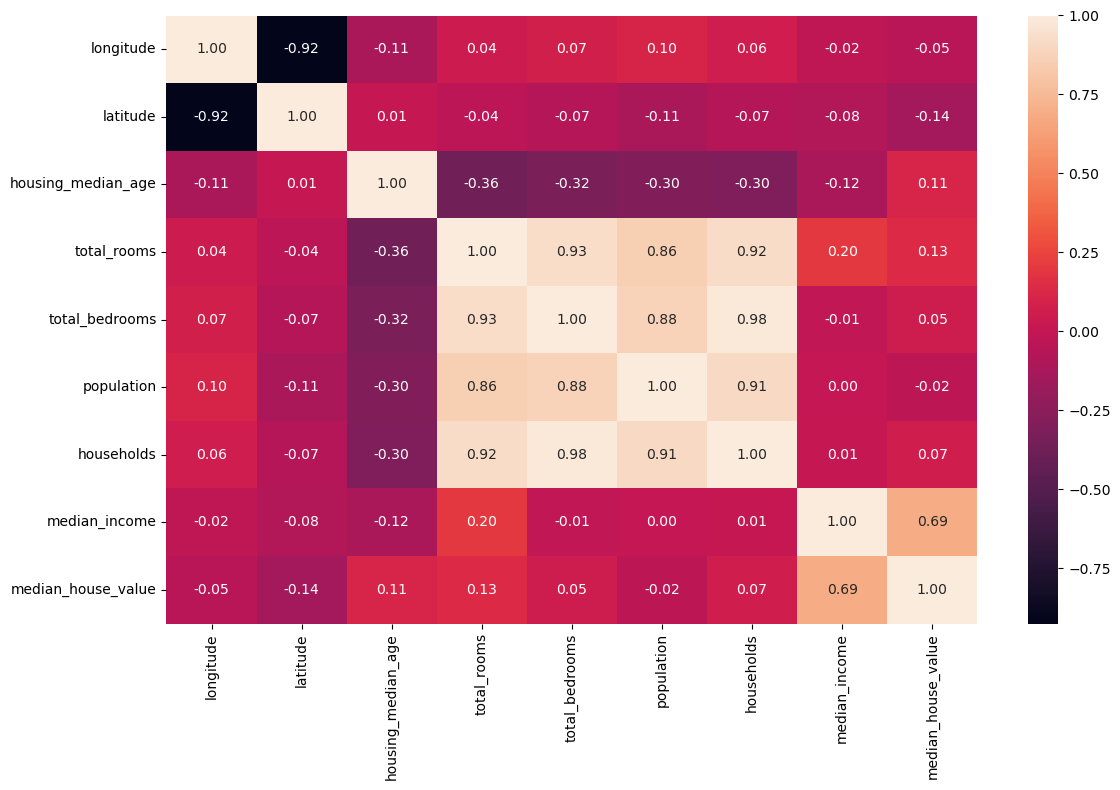

In [11]:
corr_matrix = housing_num.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.tight_layout()

### 3.4 Feature Distributions

Histograms of every numeric column in one shot. This surfaces skewness (e.g., right-skewed income and room counts), the capped/censored values mentioned above (visible as an artificial spike at the max bin), and rough scale differences between features — all of which justify the `StandardScaler` step used later in the preprocessing pipeline.

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

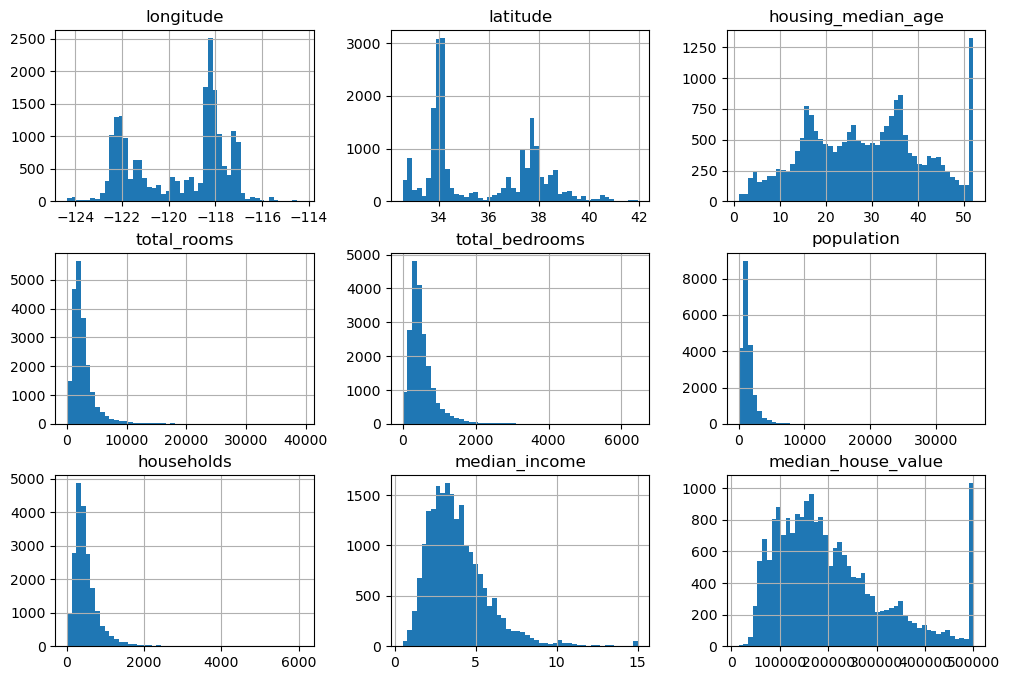

In [12]:
housing_df.hist(bins=50, figsize=(12, 8))

## 4. Feature Engineering

### 4.1 Income Stratification (`income_cat`)

`median_income` is the single strongest predictor of `median_house_value` (per the correlation matrix above), but it is a continuous, right-skewed variable. Binning it into discrete income categories serves two purposes:

- It creates a interpretable, ordinal grouping of income levels for exploratory analysis.
- It is the standard building block for **stratified sampling** in this dataset (as in Géron's *Hands-On Machine Learning*), ensuring that the train/test split preserves the real-world income distribution rather than risking a skewed split from pure randomness.

The bin edges `[0, 1.5, 3.0, 4.5, 6.0, np.inf]` (income measured in tens of thousands of USD) are chosen to roughly balance the number of districts per category while keeping the boundaries at intuitive round numbers.

$$
\text{income\_cat} =
\begin{cases}
1 & \text{median\_income} \in (0, 1.5] \\
2 & \text{median\_income} \in (1.5, 3.0] \\
3 & \text{median\_income} \in (3.0, 4.5] \\
4 & \text{median\_income} \in (4.5, 6.0] \\
5 & \text{median\_income} \in (6.0, \infty)
\end{cases}
$$

> **Note:** `income_cat` is created here to demonstrate awareness of stratified sampling as a best practice. In the current pipeline, the actual `train_test_split` below uses a plain random split rather than `stratify=income_cat` — a natural next iteration would be to wire the two together to further reduce sampling variance in the evaluation metrics.


In [13]:
housing_df['income_cat'] = pd.cut(housing_df['median_income'], bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf], labels=[1, 2, 3, 4, 5])

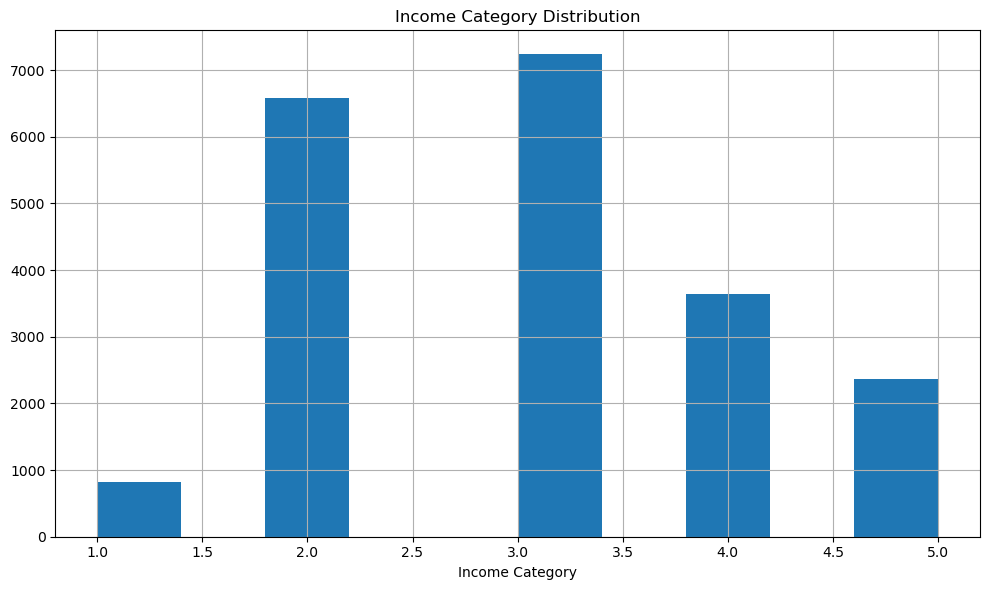

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(x='income_cat', data=housing_df)
plt.title('Income Category Distribution')
plt.xlabel('Income Category')
plt.grid(True)
plt.tight_layout()

### 4.2 Geospatial Visualization

California housing prices are heavily driven by *location* (coastal proximity, major metro areas). Plotting every district by latitude/longitude and color-coding by `median_house_value` turns two numeric columns into an intuitive geographic price map — this is a sanity check that the model will later need to capture this spatial signal (implicitly, since latitude/longitude are fed in directly as numeric features).

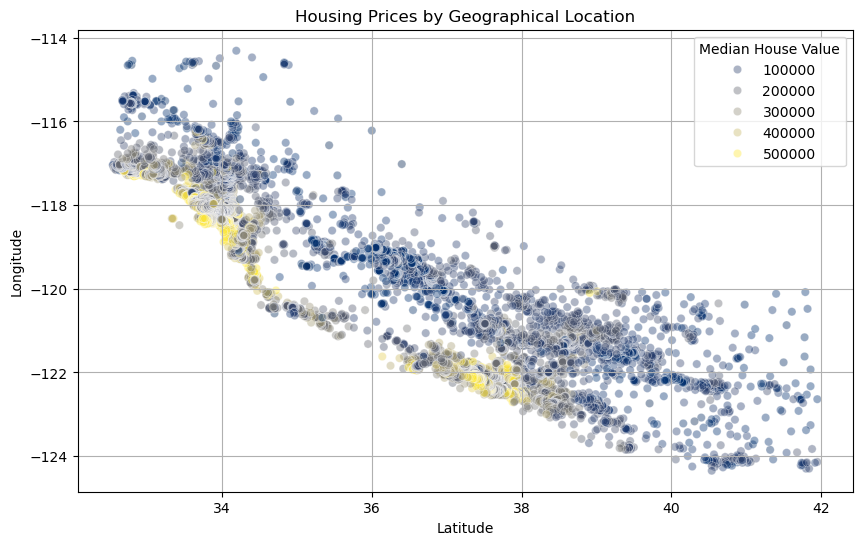

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='latitude', y='longitude', palette='cividis', hue='median_house_value', alpha=0.4, data=housing_df)
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("Housing Prices by Geographical Location")
plt.legend(title="Median House Value")
plt.grid(True)

In [16]:
x = housing_df.drop('median_house_value', axis=1)
y = housing_df['median_house_value']

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### 5.2 Building the Preprocessing Pipeline

Different column types need fundamentally different treatment, and doing this manually (outside a `Pipeline`) is a common source of **data leakage** — e.g., accidentally fitting a scaler on the full dataset instead of just the training fold. Using `scikit-learn` `Pipeline` + `ColumnTransformer` solves this cleanly:

- **Numeric columns** → median imputation (robust to outliers, unlike mean imputation) followed by standardization (zero mean, unit variance), which matters for `LinearRegression` and generally improves numerical stability.
- **Categorical columns** (`ocean_proximity`) → one-hot encoding, with `handle_unknown='ignore'` so that any category seen at inference time but not during training doesn't crash the pipeline.

Critically, the entire `preprocessor` object is **fit only on `x_train`** and then merely *applied* (`.transform`) to `x_test` — this guarantees the test set's statistics (e.g. medians, means, category sets) never leak into training.

In [18]:
numerical_featutes = x.select_dtypes(include=['int64', 'float64']).columns
categorical_features = x.select_dtypes(include=['object']).columns

In [19]:
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [20]:
categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [21]:
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_featutes),
    ("cat", categorical_pipeline, categorical_features)
])

In [22]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [23]:
print("Training shape:", x_train_processed.shape)
print("Testing shape:", x_test_processed.shape)

print("\nFeature names:")
print(preprocessor.get_feature_names_out())

Training shape: (16512, 13)
Testing shape: (4128, 13)

Feature names:
['num__longitude' 'num__latitude' 'num__housing_median_age'
 'num__total_rooms' 'num__total_bedrooms' 'num__population'
 'num__households' 'num__median_income' 'cat__ocean_proximity_<1H OCEAN'
 'cat__ocean_proximity_INLAND' 'cat__ocean_proximity_ISLAND'
 'cat__ocean_proximity_NEAR BAY' 'cat__ocean_proximity_NEAR OCEAN']


## 6. Modeling

### Model Selection Rationale

Three models spanning different bias/variance and interpretability trade-offs are benchmarked side by side rather than committing to a single algorithm upfront:

| Model | Why it's included |
|---|---|
| **Linear Regression** | Fast, interpretable baseline. Establishes the performance floor and tests whether the (mostly linear) correlations seen in EDA are sufficient on their own. |
| **Random Forest Regressor** | Bagged ensemble of decision trees; captures non-linear feature interactions (e.g., location × income) and is robust to outliers/skew without requiring feature scaling. `n_estimators=200` balances variance reduction against training time; `n_jobs=-1` parallelizes across all available cores. |
| **Gradient Boosting Regressor** | Sequential boosted ensemble that typically achieves lower bias than bagging by iteratively correcting prior errors — often the strongest of the three on tabular data like this, at the cost of longer training time. |

Comparing all three on identical train/test splits and identical preprocessed inputs makes the benchmark fair and the eventual model choice defensible.

In [24]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42),
}

In [25]:
results_list = []

### Training & Evaluation Loop

Each model is trained on the identical preprocessed training set and evaluated on the identical held-out test set, so performance differences reflect the algorithms themselves rather than differences in data handling. Per-model predictions are also exported to CSV (`{model_name}_output.csv`) alongside the original test features — useful for downstream error analysis (e.g., filtering to the largest residuals to look for systematic bias by location or income bracket).

In [26]:
for name, model in models.items():
    print(f"Training and Evaluating: {name}...")

    model.fit(x_train_processed, y_train)

    y_pred = model.predict(x_test_processed) 

    output_df = x_test.copy()

    output_df['Actual_price'] = y_test.values
    output_df['Predicted_Price'] = y_pred

    output_df.to_csv(f"{name}_output.csv", index=False)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)
    
    results_list.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2_Score": r2,
    })

    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.4f}")
    print("-" * 50)

Training and Evaluating: Linear Regression...
MAE: 50670.49
RMSE: 70059.19
R² Score: 0.6254
--------------------------------------------------
Training and Evaluating: Random Forest Regressor...
MAE: 31465.25
RMSE: 48781.91
R² Score: 0.8184
--------------------------------------------------
Training and Evaluating: Gradient Boosting Regressor...
MAE: 38278.15
RMSE: 55903.12
R² Score: 0.7615
--------------------------------------------------


In [27]:
results_df = pd.DataFrame(results_list)
results_df

,Model,MAE,MSE,RMSE,R2_Score
0,Linear Regression,50670.489236,4.908291e+09,70059.193339,0.625438
1,Random Forest Regressor,31465.253847,2.379675e+09,48781.911007,0.818402
2,Gradient Boosting Regressor,38278.148174,3.125159e+09,55903.124191,0.761513


## 7. Evaluation & Insights

With all three models trained on identical data, the results table and accompanying charts turn raw metrics into a side-by-side comparison. The goal here is not just to report numbers, but to draw a conclusion: **which model would I actually recommend for production, and why?**

- **RMSE** is the primary metric to minimize — it's in the same units as `median_house_value` (USD) and penalizes large mispredictions more than MAE does, which matters for a pricing use case where big misses are costly.
- **R²** contextualizes RMSE by showing what fraction of price variance the model explains — useful for communicating model quality to non-technical stakeholders.
- Comparing **Linear Regression** against the two ensembles quantifies how much predictive lift comes from capturing non-linear feature interactions (e.g., the geographic clustering seen in the EDA scatterplot) versus what a simple linear combination of features can achieve.


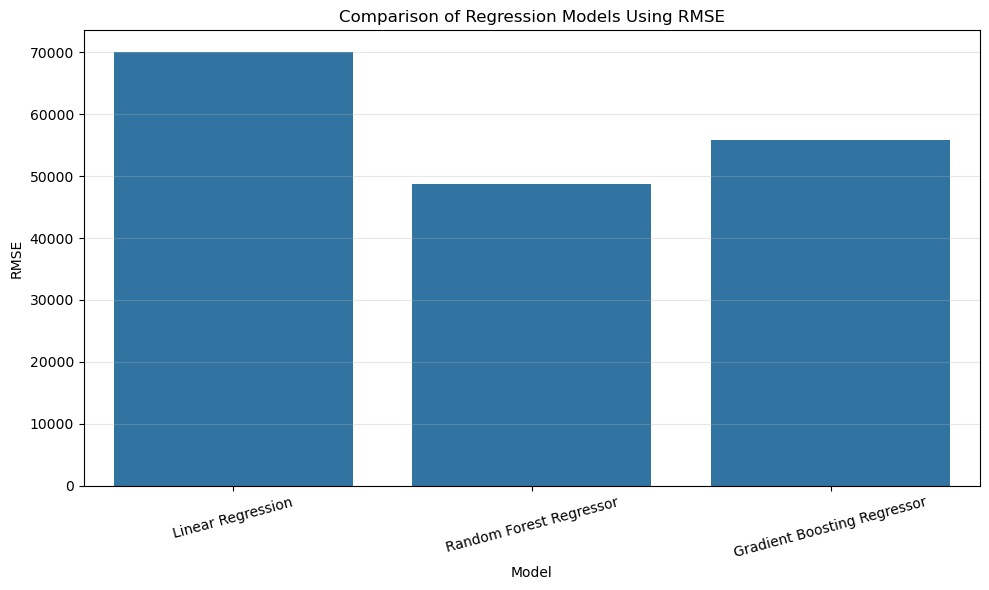

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='RMSE', data=results_df)
plt.title("Comparison of Regression Models Using RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

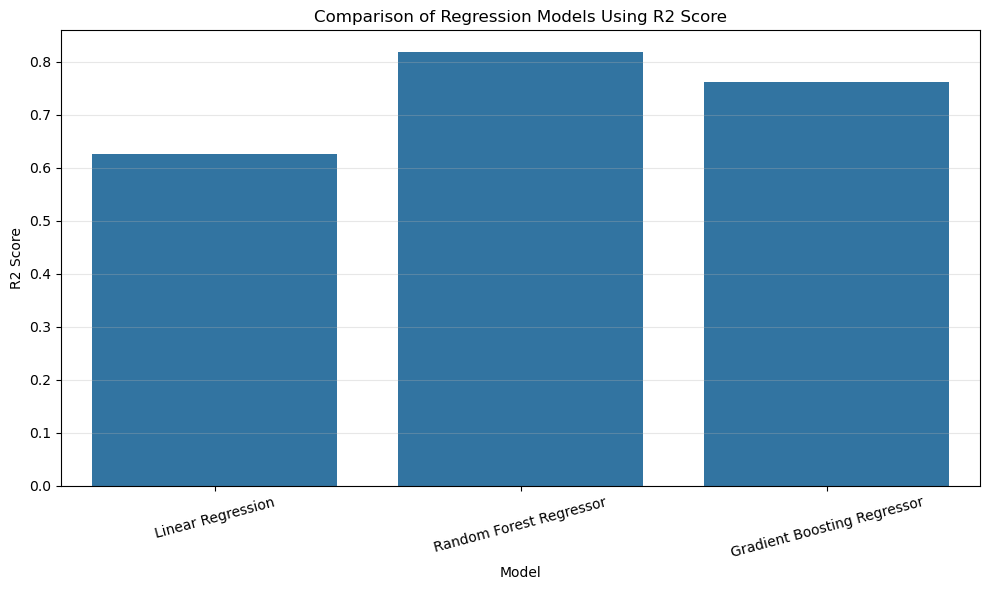

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2_Score', data=results_df)
plt.title("Comparison of Regression Models Using R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

## 8. Conclusion & Next Steps

**Key takeaways to highlight in an interview setting:**

- The ensemble tree models (Random Forest, Gradient Boosting) are expected to outperform the Linear Regression baseline on RMSE/R², confirming that non-linear feature interactions — particularly geographic clustering and income effects — carry real predictive signal beyond what a linear model can capture.
- The preprocessing pipeline (median imputation, standard scaling, one-hot encoding) is fit exclusively on the training set and reused on the test set via `ColumnTransformer`, which avoids data leakage and mirrors how this system would be deployed in production (fit once, serve many predictions).

**Potential next iterations:**
- Wire the `income_cat` stratification into `train_test_split(..., stratify=...)` to reduce sampling variance in the reported metrics.
- Engineer ratio features such as `rooms_per_household`, `bedrooms_per_room`, and `population_per_household`, which are known to improve on the raw counts for this dataset.
- Hyperparameter-tune the Random Forest / Gradient Boosting models (e.g., via `GridSearchCV` or `RandomizedSearchCV`) rather than relying on default/lightly-tuned parameters.
- Perform residual analysis (error vs. latitude/longitude, error vs. income) to identify where the best model systematically over- or under-predicts.
